# Grad-CAM and Modified GradCam++ -- Malaria Detection
## VGG-19 · ResNet-50 · MobileNetV2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.resnet_v2  import preprocess_input as resnet_v2_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess


2026-03-13 21:43:57.621005: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 21:43:57.668091: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 21:43:59.163179: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ssahoo/anaconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: Futu

In [2]:
CLASS_NAMES = ['Parasitized', 'Uninfected']

## 1. Image Preprocessing
> Each model was trained with a different preprocessing — must match exactly at inference.

In [3]:
def load_and_preprocess_image_resnet50(img_path):
    """Loads an image and formats it EXACTLY for ResNet-50.
    Training used: resnet50.preprocess_input (scales to [-1, 1])
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_array   = np.expand_dims(img_resized, axis=0)
    img_preprocessed = resnet50_preprocess(img_array.astype(np.float32))

    return img_rgb, img_preprocessed


In [5]:
def load_and_preprocess_image_vgg19(img_path):
    """Loads an image and formats it EXACTLY for VGG-19.
    Training used: ImageDataGenerator(rescale=1./255) — simple [0, 1] scaling.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img_rgb      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized  = cv2.resize(img_rgb, (224, 224))
    img_array    = np.expand_dims(img_resized, axis=0)
    img_preprocessed = img_array.astype(np.float32) / 255.0

    return img_rgb, img_preprocessed


In [6]:
def load_and_preprocess_image_mobilenetv2(img_path):
    """Loads an image and formats it EXACTLY for MobileNetV2.
    Training used: mobilenet_v2.preprocess_input (scales to [-1, 1])
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img_rgb      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized  = cv2.resize(img_rgb, (224, 224))         # matches target_size
    img_array    = np.expand_dims(img_resized, axis=0).astype(np.float32)
    img_preprocessed = mobilenet_preprocess(img_array)     # scales to [-1, 1]

    return img_rgb, img_preprocessed


In [ ]:
# ── UPDATE THIS PATH ──────────────────────────────────────────
img_path = "malaria7.png"

original_img,         preprocessed_resnet50    = load_and_preprocess_image_resnet50(img_path)
original_img,         preprocessed_vgg19        = load_and_preprocess_image_vgg19(img_path)
original_img,         preprocessed_mobilenetv2  = load_and_preprocess_image_mobilenetv2(img_path)

print(f"Image loaded         : {img_path}")
print(f"Original shape       : {original_img.shape}")
print(f"ResNet-50 range      : [{preprocessed_resnet50.min():.2f}, {preprocessed_resnet50.max():.2f}]")
print(f"VGG-19 range         : [{preprocessed_vgg19.min():.2f}, {preprocessed_vgg19.max():.2f}]")
print(f"MobileNetV2 range    : [{preprocessed_mobilenetv2.min():.2f}, {preprocessed_mobilenetv2.max():.2f}]")


Image loaded         : malaria7.png
Original shape       : (118, 94, 3)
ResNet-50 range      : [-123.68, 103.32]
VGG-19 range         : [0.00, 0.89]
MobileNetV2 range    : [-1.00, 0.79]


## 2. Load Models

In [ ]:
from tensorflow.keras.models import load_model

RESNET50_PATH      = "resnet50_malaria.keras"
VGG19_PATH         = "vgg19_malaria.keras"
MOBILENETV2_PATH   = "mobilenet_malaria.keras"

# ── ResNet-50 ─────────────────────────────────────────────────
print("Loading ResNet-50 ...", end=" ")
resnet50_model = load_model(RESNET50_PATH, compile=False, safe_mode=False)
print(f"({resnet50_model.count_params():,} params)")

print()

# ── VGG-19 ───────────────────────────────────────────────────
print("Loading VGG-19 ...", end=" ")
vgg19_model = load_model(VGG19_PATH, compile=False, safe_mode=False)
print(f"({vgg19_model.count_params():,} params)")

print()

# ── MobileNetV2 ──────────────────────────────────────────────
print("Loading MobileNetV2 ...", end=" ")
mobilenetv2_model = load_model(MOBILENETV2_PATH, compile=False, safe_mode=False)
print(f"({mobilenetv2_model.count_params():,} params)")


Loading ResNet-50 ... (24,637,826 params)

(26,080,194 params)0 ... 

(20,288,066 params)

(2,914,882 params)2 ... 


In [ ]:
# Last convolutional layer for each model
# This is the layer Grad-CAM/ILCAN will hook into

# ResNet-50: last residual block output before GAP
LAST_CONV_RESNET50 = "conv5_block3_out"

# VGG-19: last conv layer in block 5
LAST_CONV_VGG19 = "block5_conv4"

# MobileNetV2: last activation before GAP
LAST_CONV_MOBILENETV2 = "out_relu"

print(f"ResNet-50     last conv : {LAST_CONV_RESNET50}")
# print(f"SE-ResNet-50  last conv : {LAST_CONV_SE_RESNET50}")
print(f"VGG-19        last conv : {LAST_CONV_VGG19}")
print(f"MobileNetV2   last conv : {LAST_CONV_MOBILENETV2}")


ResNet-50     last conv : conv5_block3_out
VGG-19        last conv : block5_conv4
MobileNetV2   last conv : out_relu


## 3. Predict

In [ ]:
def predict_image(model, preprocessed_img, model_name=""):
    """Generates prediction and returns class index, label and confidence."""
    preds      = model.predict(preprocessed_img, verbose=0)
    class_idx  = np.argmax(preds[0])
    confidence = preds[0][class_idx]
    class_label = CLASS_NAMES[class_idx]

    tag = f"[{model_name}] " if model_name else ""
    print(f"{tag}Prediction : {class_label}")
    print(f"{tag}Confidence : {confidence:.2%}")
    print()
    return class_idx, class_label, confidence

print("=" * 50)
pred_idx_resnet50,    label_resnet50,    conf_resnet50    = predict_image(resnet50_model,    preprocessed_resnet50,    "ResNet-50")
pred_idx_vgg19,       label_vgg19,       conf_vgg19       = predict_image(vgg19_model,       preprocessed_vgg19,       "VGG-19")
pred_idx_mobilenetv2, label_mobilenetv2, conf_mobilenetv2 = predict_image(mobilenetv2_model, preprocessed_mobilenetv2, "MobileNetV2")
print("=" * 50)


[ResNet-50] Prediction : Uninfected
[ResNet-50] Confidence : 59.84%

[VGG-19] Prediction : Parasitized
[VGG-19] Confidence : 81.99%

[MobileNetV2] Prediction : Uninfected
[MobileNetV2] Confidence : 58.35%



## 4. Grad-CAM

In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # Cast image to tensor
        img_tensor = tf.cast(img_array, tf.float32)

        # Get the outputs
        conv_outputs, predictions = grad_model(img_tensor)

        # SAFETY CHECK: Unwrap lists if Keras 3 returns them
        if isinstance(predictions,  (list, tuple)): predictions  = predictions[0]
        if isinstance(conv_outputs, (list, tuple)): conv_outputs = conv_outputs[0]

        # Watch conv_outputs explicitly — prevents None gradients
        tape.watch(conv_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pool gradients → channel weights (Eq. 3)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # (C,)

    # Weighted sum of feature maps (Eq. 2)
    conv_outputs = conv_outputs[0]                                      # (H, W, C)
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]         # (H, W, 1)
    heatmap      = tf.squeeze(heatmap)                                  # (H, W)

    # ReLU + safe normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


In [ ]:
heatmap_gradcam_resnet50    = make_gradcam_heatmap(preprocessed_resnet50,    resnet50_model,    LAST_CONV_RESNET50,    pred_idx_resnet50)
heatmap_gradcam_vgg19       = make_gradcam_heatmap(preprocessed_vgg19,       vgg19_model,       LAST_CONV_VGG19,       pred_idx_vgg19)
heatmap_gradcam_mobilenetv2 = make_gradcam_heatmap(preprocessed_mobilenetv2, mobilenetv2_model, LAST_CONV_MOBILENETV2, pred_idx_mobilenetv2)

print("Grad-CAM heatmaps generated ✓")
print(f"  ResNet-50    heatmap shape : {heatmap_gradcam_resnet50.shape}")
print(f"  VGG-19       heatmap shape : {heatmap_gradcam_vgg19.shape}")
print(f"  MobileNetV2  heatmap shape : {heatmap_gradcam_mobilenetv2.shape}")


Grad-CAM heatmaps generated ✓
  ResNet-50    heatmap shape : (4, 4)
  VGG-19       heatmap shape : (14, 14)
  MobileNetV2  heatmap shape : (7, 7)


## 6.Modified Grad-CAM++

In [13]:
def make_ilcan_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Key difference from standard Grad-CAM++:
      Standard : grads2 = (dF/dA)^2          algebraic APPROXIMATION
      ILCAN    : grads2 = tape2.gradient()    TRUE 2nd order derivative

    Equations from paper:
      Eq. 7 : alpha^k_{ij} = (d2F/dA2) / (2*(d2F/dA2) + sum(A)*(d3F/dA3))
      Eq. 4 : w^k_c = sum_{i,j} alpha * ReLU(dF/dA)
      Eq. 8 : M^c   = ReLU( sum_k w^k_c * A^k )
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    # TWO nested tapes for TRUE 2nd order derivative
    # tape1: computes 1st derivative  dF^c/dA
    # tape2: computes 2nd derivative  d(dF^c/dA)/dA = d2F^c/dA2
    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            conv_outputs, predictions = grad_model(img_tensor)

            # SAFETY CHECK: Unwrap Keras 3 lists/tuples
            if isinstance(predictions,  (list, tuple)): predictions  = predictions[0]
            if isinstance(conv_outputs, (list, tuple)): conv_outputs = conv_outputs[0]

            # Watch in BOTH tapes
            tape1.watch(conv_outputs)
            tape2.watch(conv_outputs)

            if pred_index is None:
                pred_index = tf.argmax(predictions[0])

            class_channel = predictions[:, pred_index]

        # TRUE 1st derivative: dF^c/dA (Eq. 7 numerator base)
        grads = tape1.gradient(class_channel, conv_outputs)

    # TRUE 2nd derivative: d2F^c/dA2 (gradient of gradient)
    grads2 = tape2.gradient(grads, conv_outputs)

    # Strip batch dimensions
    conv_outputs = conv_outputs[0]   # (H, W, C)
    grads        = grads[0]          # (H, W, C)
    grads2       = grads2[0]         # (H, W, C) — TRUE 2nd derivative

    # 3rd derivative: approximated as grads * grads2
    grads3 = grads * grads2

    # Alpha (Eq. 7)
    sum_activations = tf.reduce_sum(conv_outputs, axis=(0, 1))   # (C,)
    denominator     = 2.0 * grads2 + (sum_activations * grads3)
    denominator     = tf.where(
        tf.abs(denominator) > 1e-8,
        denominator,
        tf.ones_like(denominator)
    )
    alphas = grads2 / denominator

    # Weights (Eq. 4)
    weights = tf.reduce_sum(alphas * tf.maximum(grads, 0.0), axis=(0, 1))   # (C,)

    # Saliency map M^c (Eq. 8)
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)   # (H, W)
    heatmap = tf.maximum(heatmap, 0.0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


In [ ]:
heatmap_ilcan_resnet50    = make_ilcan_heatmap(preprocessed_resnet50,    resnet50_model,    LAST_CONV_RESNET50,    pred_idx_resnet50)
heatmap_ilcan_vgg19       = make_ilcan_heatmap(preprocessed_vgg19,       vgg19_model,       LAST_CONV_VGG19,       pred_idx_vgg19)
heatmap_ilcan_mobilenetv2 = make_ilcan_heatmap(preprocessed_mobilenetv2, mobilenetv2_model, LAST_CONV_MOBILENETV2, pred_idx_mobilenetv2)

print("ILCAN heatmaps generated ✓")


ILCAN heatmaps generated ✓


## 7. Visualization

In [15]:
def superimpose_heatmap(original_img, heatmap, alpha=0.4):
    """Overlays heatmap on image. alpha=0.4 → 40% heatmap, 60% image."""
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    jet             = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    jet             = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(
        original_img.astype(np.float32), 1 - alpha,
        jet.astype(np.float32),          alpha, 0
    ).astype(np.uint8)


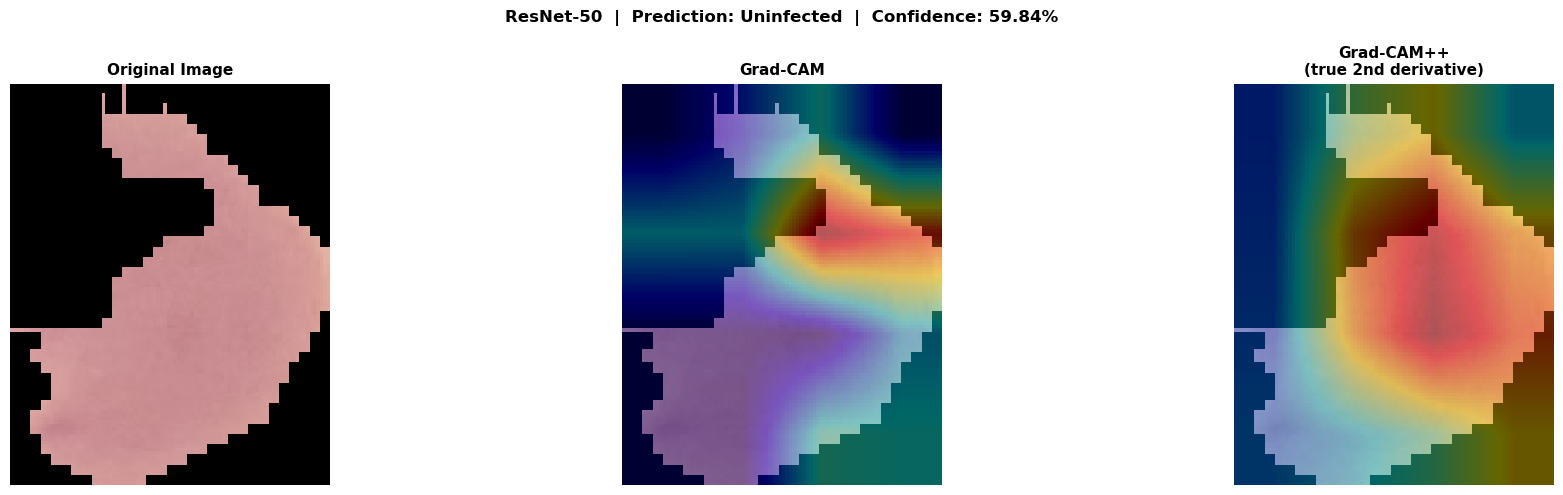

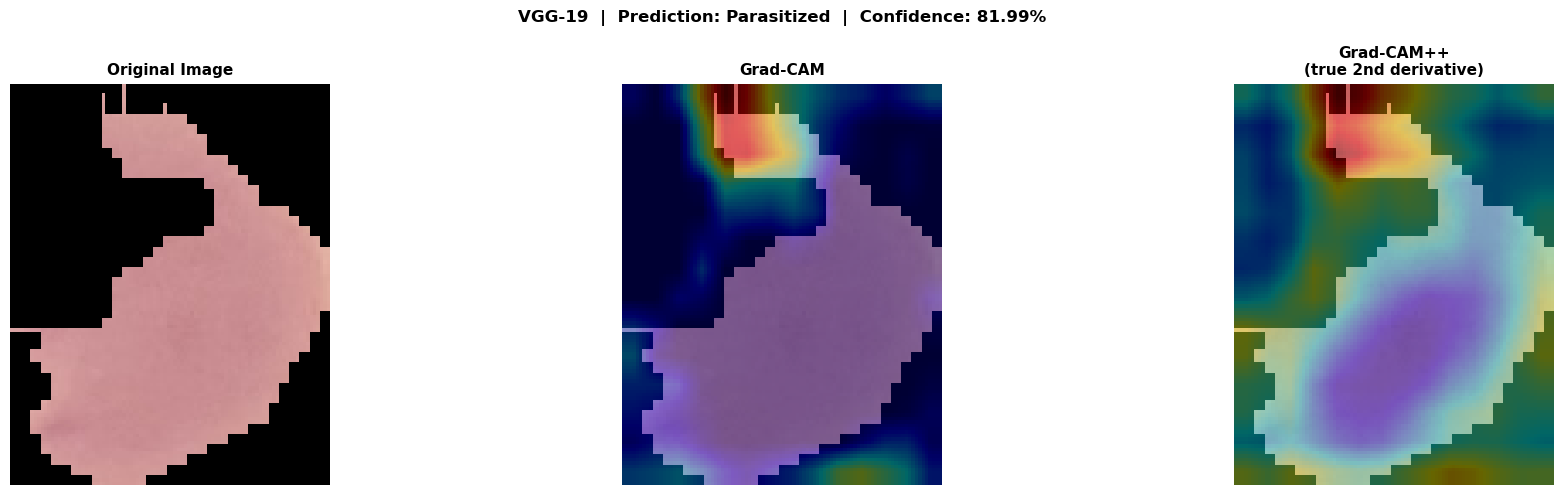

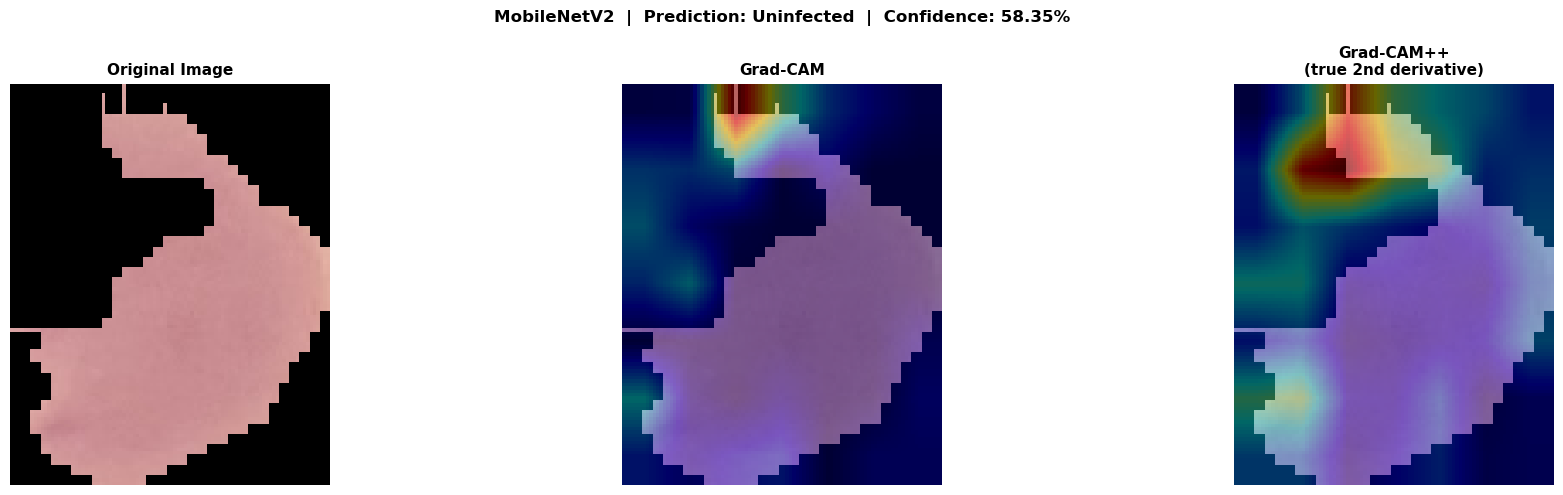

In [16]:
def plot_model_results(original_img, heatmap_gradcam, heatmap_ilcan,
                       model_name, class_label, confidence):
    """3-panel: Original | Grad-CAM | ILCAN"""
    overlay_gradcam   = superimpose_heatmap(original_img, heatmap_gradcam)
    overlay_ilcan     = superimpose_heatmap(original_img, heatmap_ilcan)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Original Image", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(overlay_gradcam)
    axes[1].set_title("Grad-CAM", fontsize=11, fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(overlay_ilcan)
    axes[2].set_title("Grad-CAM++\n(true 2nd derivative)", fontsize=11, fontweight="bold")
    axes[2].axis("off")

    fig.suptitle(
        f"{model_name}  |  Prediction: {class_label}  |  Confidence: {confidence:.2%}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

# ── Plot for all models ───────────────────────────────────────
plot_model_results(original_img,
                   heatmap_gradcam_resnet50, heatmap_ilcan_resnet50,
                   "ResNet-50", label_resnet50, conf_resnet50)

# plot_model_results(original_img,
#                    heatmap_gradcam_se_resnet50, heatmap_ilcan_se_resnet50,
#                    "SE-ResNet-50", label_se_resnet50, conf_se_resnet50)

plot_model_results(original_img,
                   heatmap_gradcam_vgg19, heatmap_ilcan_vgg19,
                   "VGG-19", label_vgg19, conf_vgg19)

plot_model_results(original_img,
                   heatmap_gradcam_mobilenetv2, heatmap_ilcan_mobilenetv2,
                   "MobileNetV2", label_mobilenetv2, conf_mobilenetv2)
